In [1]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform
from astroML import stats as astroMLstats

C:\Users\havef\OneDrive\Documents\conda\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
N_data = 100
N_mu = 100
mu = 1
sigma = 0.2

#defining arrays 
data = np.array([])
sigma_gen = np.array([])
LH = np.array([])
distance = np.array([])

### HOMO/HETERO SCEDASTIC CASE


In [3]:
#defining the distibution with the parameters
distG = norm(loc=mu, scale=sigma)
a = np.linspace(-3 , 3 , 10000)

#generating points (HOMO) 
data = np.random.normal(mu, sigma,N_data)
#for i in range (N_data):                          #<----to become homoscedastic just delete the '#'
#    sigma_gen = np.append(sigma_gen, sigma)       # in front of these lines and add it on the line below
    
#ggenerating points (HETERO)
sigma_gen = np.random.normal(0.2, 0.05,N_data)     #<----to become heteroscedastic just delete the '#'
                                                   # in front of this line and add it on the two lines above

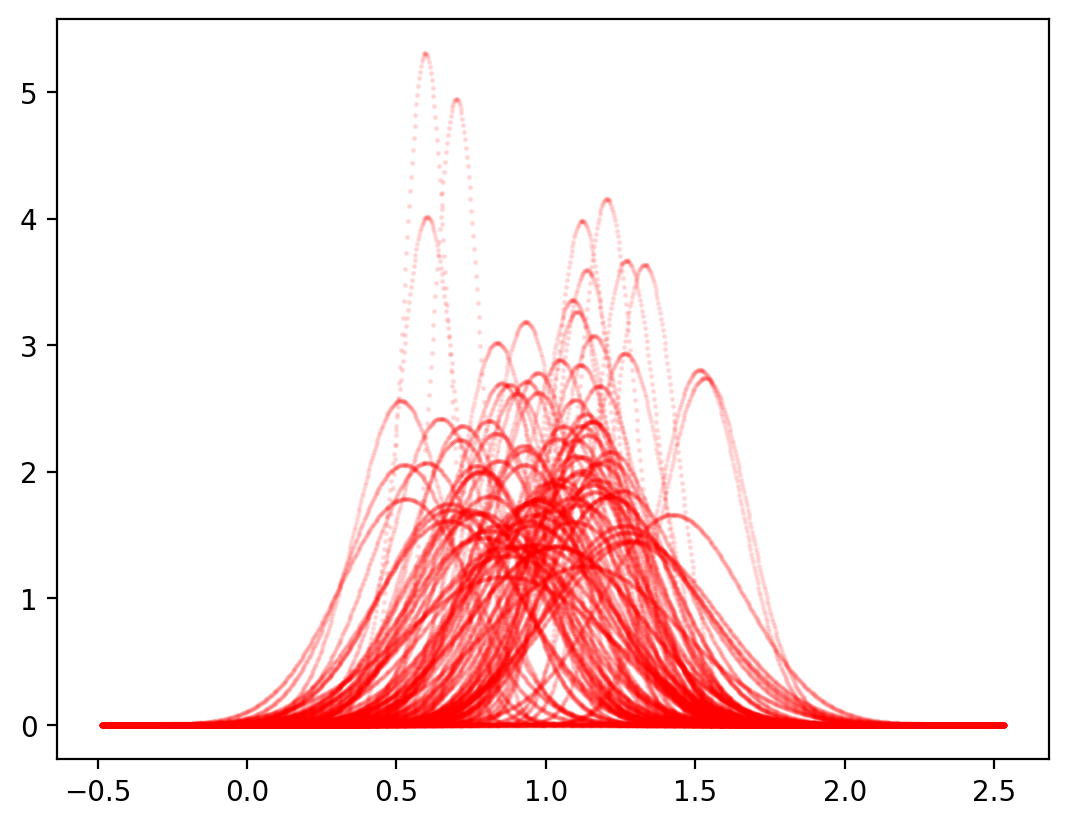

In [10]:


#computing likelihoods of {xi} (product of single likelihoods)
mu = np.linspace(0.5 , 1.5 , N_mu)
single_LH = np.ones((N_data,N_mu))

for j in range (N_mu):
    for i in range (N_data):
        single_LH[i][j] = np.exp((-((data[i] - mu[j])**2)/(2*sigma_gen[i]**2)))

tot_LH = np.array([])
for i in range(N_mu):
    tot_LH = np.append(tot_LH, np.prod(single_LH[:,i]))

for i in range (N_data):
    #plt.scatter(data, single_LH[:,i], s=1)
    Xgrid = np.linspace(min(data)-1,max(data)+1,1000)
    plt.scatter(Xgrid, norm.pdf(Xgrid, data[i] ,sigma_gen[i]), s=1, color = 'red', alpha = 0.1)
plt.show()


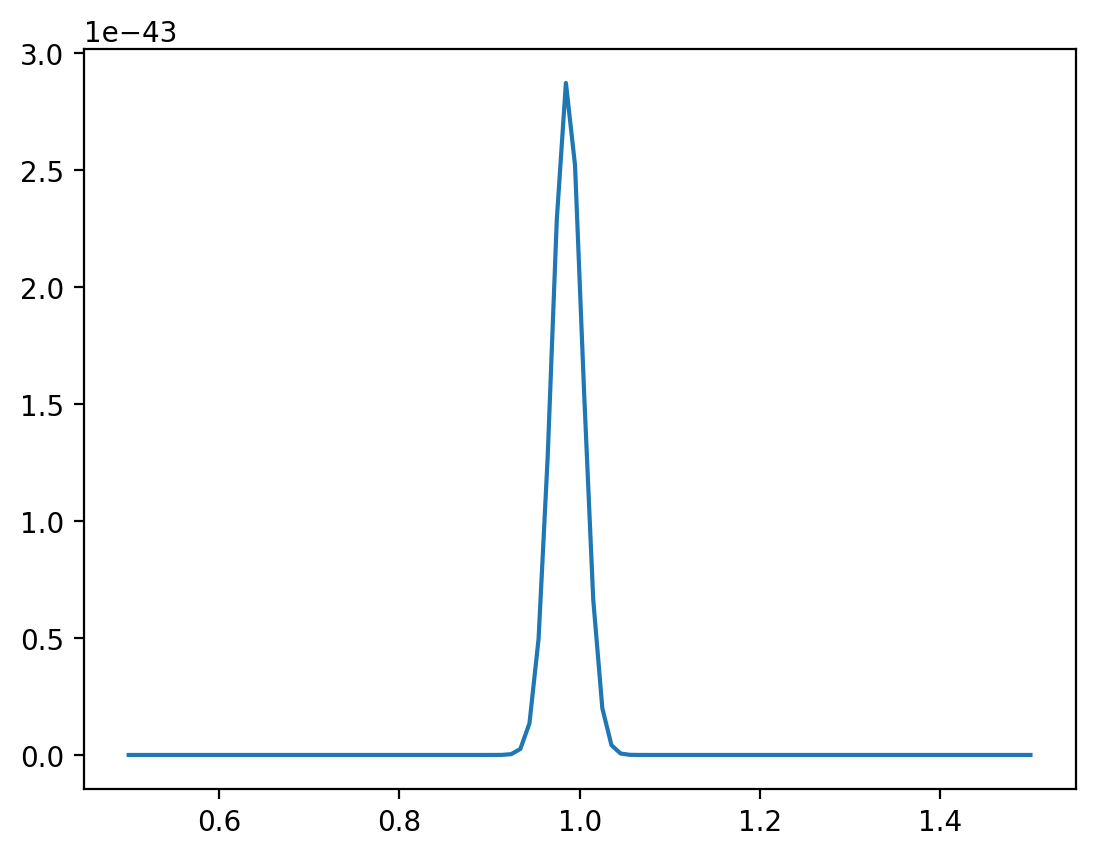

In [5]:
plt.plot(mu,tot_LH)
plt.show()

In [6]:
# Finding the maximum of the likelihood with argsort
MAX = np.where(tot_LH == np.ndarray.max(tot_LH))

#printing the mu that maximizes the likelihood
mu[MAX[0][0]]

0.9848484848484849

In [7]:
#printing the sigma that maximizes the likelihood
sigma_gen[MAX[0][0]]

0.23509477748682966

## PART 2 - Fisher matrix


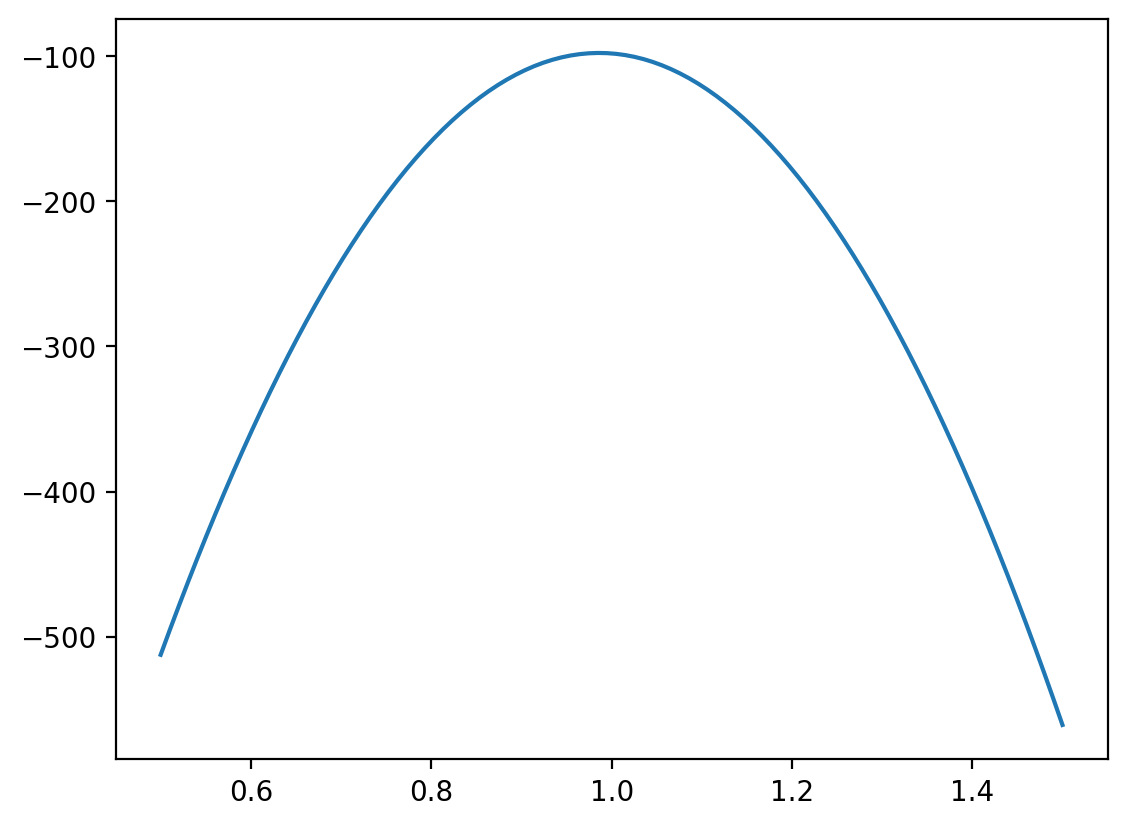

In [8]:
log_like = np.log(tot_LH + 10**(-300))
plt.plot(mu,log_like)
plt.show()

##### Finding Fisher Matrix by re-building second order derivative with "np.diff"

In [9]:
delta_mu = (1.5 - 0.5) /N_mu
#second order derivative
log_like_second = np.diff(np.diff(log_like)) / ((delta_mu)**2)
error = (np.sqrt(-1*log_like_second))**(-1)
error[MAX[0][0]]

0.016719509961057616